# Customer Dataset

In [1]:
# Load the dataset
import pandas as pd

df = pd.read_csv('../../datasets/Customer.csv')

## Exploratory Data Analysis

In [2]:
df.head()

,Customer No,Age,Income,Student,Credit Rating,Buys Computer
0,1,Youth,High,No,Fair,No
1,2,Youth,High,No,Excellent,No
2,3,Middle-aged,High,No,Fair,Yes
3,4,Senior,Medium,No,Fair,Yes
4,5,Senior,Low,Yes,Fair,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer No    173 non-null    object
 1   Age            14 non-null     object
 2   Income         14 non-null     object
 3   Student        14 non-null     object
 4   Credit Rating  14 non-null     object
 5   Buys Computer  14 non-null     object
dtypes: object(6)
memory usage: 57.0+ KB


In [4]:
df.isnull().sum()

Customer No      1041
Age              1200
Income           1200
Student          1200
Credit Rating    1200
Buys Computer    1200
dtype: int64

In [5]:
df.describe()

,Customer No,Age,Income,Student,Credit Rating,Buys Computer
count,173,14,14,14,14,14
unique,173,3,3,2,2,2
top,1,Youth,High,No,Fair,Yes
freq,1,5,5,7,8,9


In [6]:
# Remove rows with missing values
df.dropna(inplace=True)

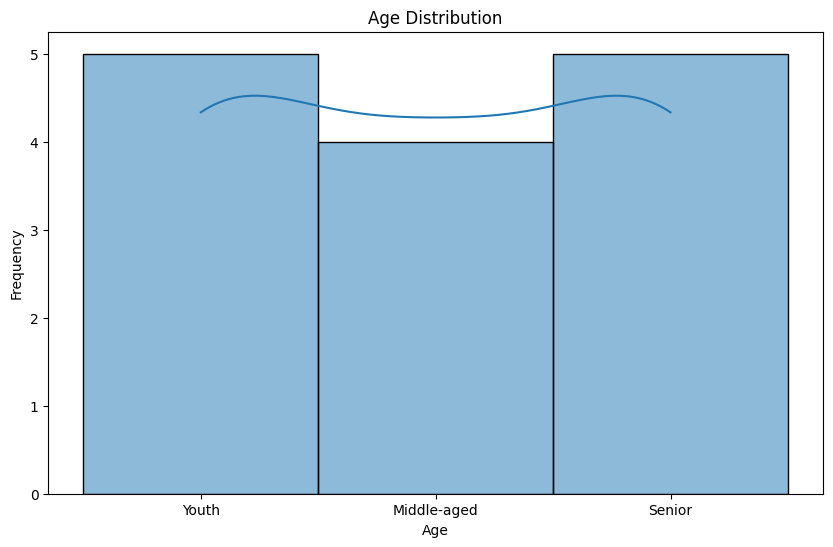

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## Model Creation

In [8]:
# Separate features and target variable
features = df.drop(labels=['Buys Computer', 'Customer No'], axis=1)
target = df['Buys Computer']

print("Features:", features.columns.tolist())
print("Target:", target.name)

Features: ['Age', 'Income', 'Student', 'Credit Rating']
Target: Buys Computer


In [9]:
# Transform categorical variables using Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer


cat_cols = features.select_dtypes(include=['object']).columns.tolist()

encoder = OrdinalEncoder()
encoder.fit_transform(features[cat_cols])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, cat_cols)
        ], 
    remainder='passthrough'
    )

In [10]:
encoder.categories_

[array(['Middle-aged', 'Senior', 'Youth'], dtype=object),
 array(['High', 'Low', 'Medium'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Excellent', 'Fair'], dtype=object)]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
# Create and train the model using a pipeline
model = DecisionTreeClassifier(criterion='gini', random_state=42)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


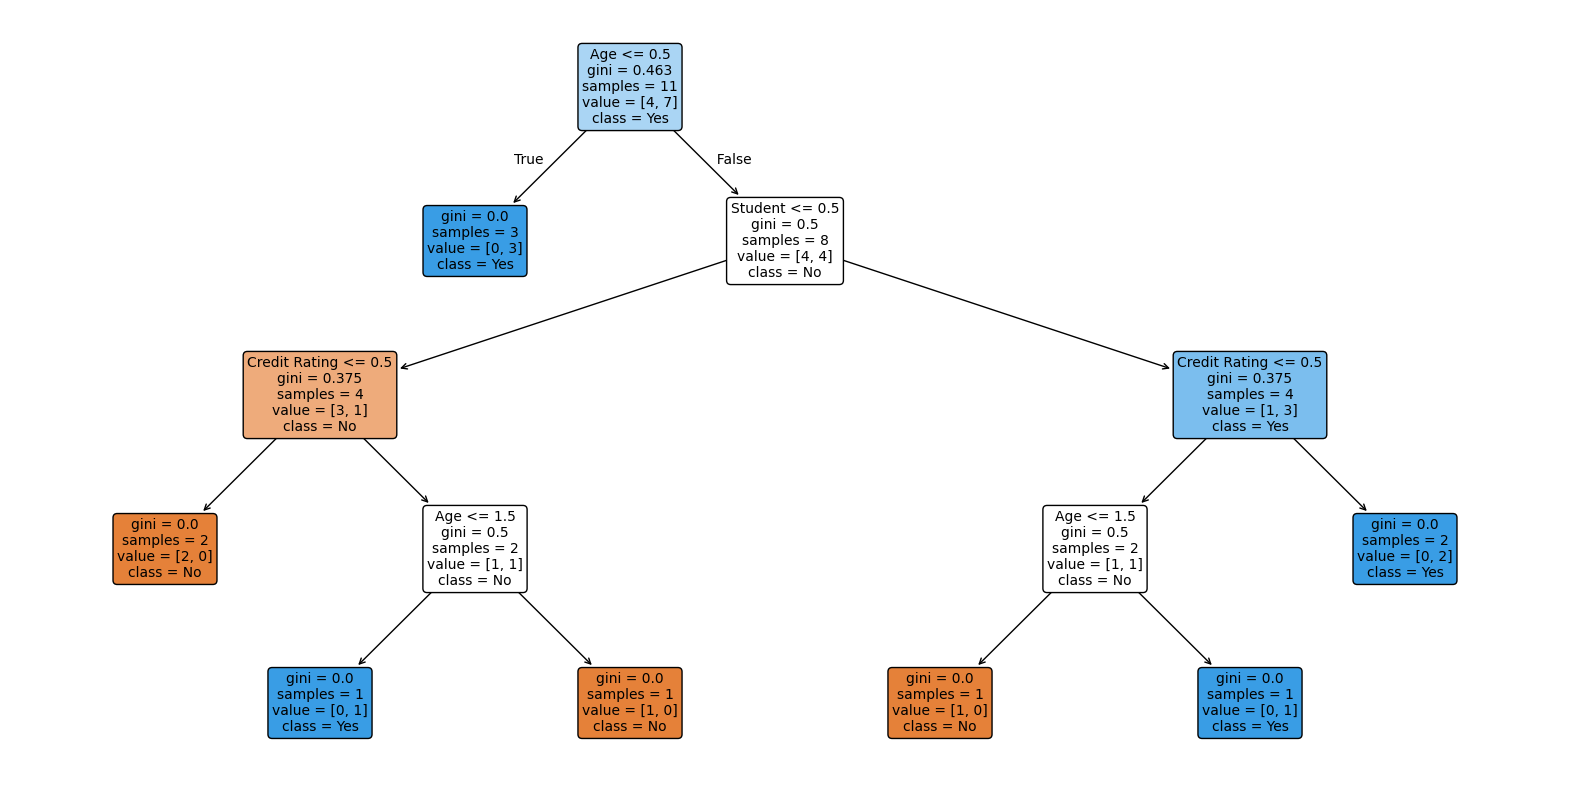

In [13]:
# Plot the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    rounded=True,
    fontsize=10,
    feature_names=features.columns,
    class_names=['No', 'Yes']
)
plt.show()

In [14]:
# Make predictions on training and testing data
X_train_pred = pipeline.predict(X_train)
X_test_pred = pipeline.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Accuracy:", accuracy_score(y_train, X_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, X_test_pred))
print("\nClassification Report:\n", classification_report(y_test, X_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, X_test_pred))

Training Accuracy: 1.0
Testing Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
 [[1 0]
 [0 2]]
